In [1]:
from jax import config
config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import jax.numpy as jnp

In [2]:
from cmap.clqt_jax import CLQT
from cmap.con_to_dis import y
from cmap.nonlinear_iclqt import par_iterate
from cmap.nonlinear_iclqt import seq_iterate
from cmap.initial_guess_nonlinear import intial_guess
from cmap.initial_guess_nonlinear import simulate
from cmap.con_to_dis import y_reverse
from cmap.linear_estimation_problem import Estimation
from cmap.convert_est_clqt import est_to_clqt

In [3]:
from nonlinear_model_ct_data import make_ct_data
from nonlinear_statespace_ct import f,h

In [4]:
steps_all=500000

In [5]:
T=50.0    

pos_std = 1e-1
vel_std = 1e-1
omega_std = 2e-1

sigma_v=5e-4
sigma_omega=0.02    

r_range=0.005
r_bearing=0.001
        
R=lambda t: jnp.array([[r_range**2 ,0],[0, r_bearing**2]])  
P0 = jnp.diag(jnp.array([pos_std**2, pos_std**2, vel_std**2, vel_std**2, omega_std**2]))
W = lambda t: jnp.eye(2)
L = lambda t:  jnp.array([
        [ 0.0, 0.0],
        [ 0.0, 0.0],
        [0.0,sigma_v],
        [0.0,sigma_v],
        [sigma_omega,0.0]
    ])
Q = lambda t: L(t) @ W(t) @ L(t).T
c = lambda t: jnp.zeros((5,))
r = lambda t: jnp.zeros((2,))
x0 = jnp.array([5.0, 5.0, 0.0, 0.3, jnp.deg2rad(0.0)])
vT = jnp.linalg.solve(P0, x0)



dt=T/steps_all

ST = jnp.linalg.solve(P0,jnp.eye(5))
F = lambda  t: jnp.eye(5)
H = lambda  t: jnp.array([[1.0, 0.0, 0.0, 0.0,0.0],
                                    [0.0, 1.0, 0.0, 0.0,0.0]])

X,y_discrete=make_ct_data(x0, P0, f, h ,L(0), steps_all,dt,sigma_v,sigma_omega,r_range,r_bearing,seed=123)
est= Estimation( F, H, c, r, L, W, R, y_discrete, P0, x0, T)


ERROR:2025-11-10 11:48:29,703:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/hassan/anaconda3/envs/pcmap/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/hassan/anaconda3/envs/pcmap/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/hassan/anaconda3/envs/pcmap/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_UNKNOWN


In [6]:
F_cl,H_cl,c_cl,r_cl,Q_cl,R_cl,T_cl,ST_cl,vT_cl,y_cl=est_to_clqt(est,steps_all)
clqt = CLQT(vT_cl, F_cl, ST_cl, Q_cl, R_cl, c_cl, H_cl, y_cl, r_cl, T_cl)

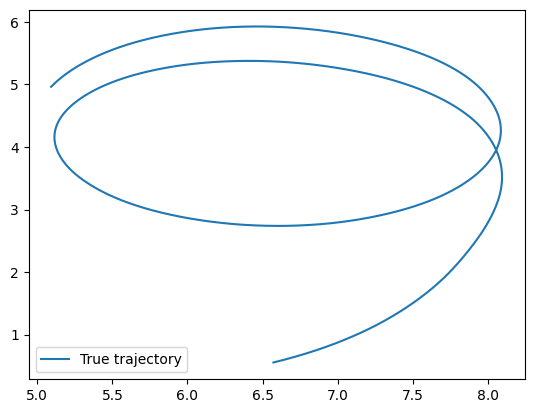

In [7]:
plt.plot(X[:,0],X[:,1],label='True trajectory')

plt.legend()
plt.show()

In [8]:
py=y_discrete[:,0]*jnp.sin(y_discrete[:,1])
px=y_discrete[:,0]*jnp.cos(y_discrete[:,1])

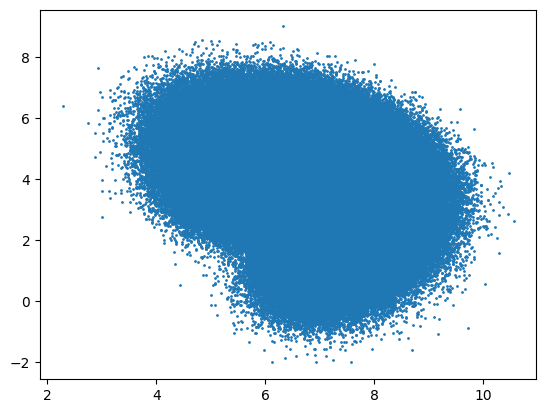

In [9]:
plt.plot(px,py,'o',markersize=1,label='Measurements')

In [10]:
_, u = intial_guess(x0, steps_all)

In [11]:
print(u)

[[0.   0.   0.01 0.01 0.  ]
 [0.   0.   0.01 0.01 0.  ]
 [0.   0.   0.01 0.01 0.  ]
 ...
 [0.   0.   0.01 0.01 0.  ]
 [0.   0.   0.01 0.01 0.  ]
 [0.   0.   0.01 0.01 0.  ]]


In [12]:
x=simulate(x0,f,u,steps_all,clqt.T/steps_all)

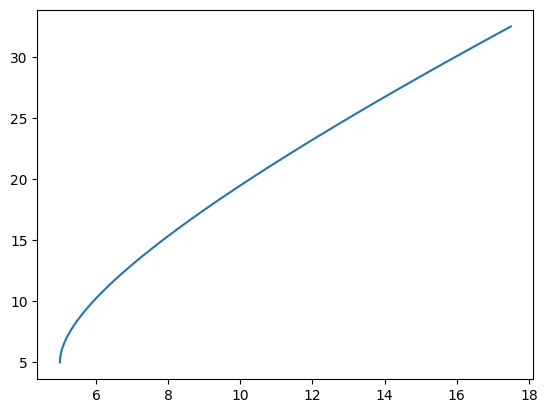

In [13]:
plt.plot(x[:,0],x[:,1])

In [14]:
# print(x.shape)

In [15]:
x_seq = x
u_seq = u
x_par = x
u_par = u
print(x_seq.shape)

(500001, 5)


In [16]:
niter=5
steps=10
blocks=steps_all//steps
t0=0.0
ST=clqt.ST

In [17]:
for i in range(niter):
 u_seq, x_seq  = seq_iterate(clqt , steps, blocks, f, h, u_seq , x_seq,t0)

In [18]:
for i in range(niter):
 u_par, x_par = par_iterate(clqt , steps, blocks, f , h, u_par , x_par,t0)

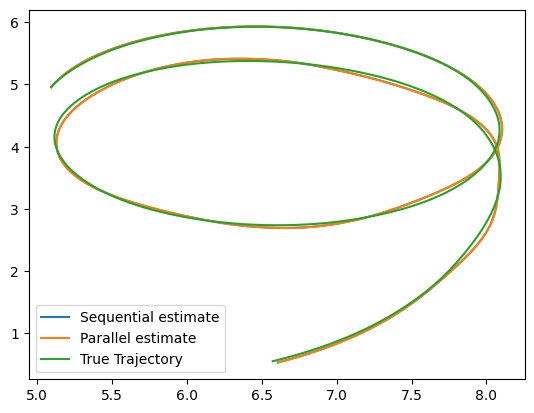

In [25]:
plt.plot(x_seq[:,0],x_seq[:,1],label='Sequential estimate')
plt.plot(x_par[:,0],x_par[:,1],label='Parallel estimate')
plt.plot(X[:,0],X[:,1],label='True Trajectory')

plt.legend()


In [20]:
jnp.max(jnp.mean(jnp.abs(x_par-x_seq)))

Array(4.386198e-05, dtype=float64)